<a href="https://colab.research.google.com/github/maschu09/mless/blob/main/remote_sensing/Random_forest_classifier_on_remote_sensing_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [ ]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [ ]:
!mkdir -p data
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv
# Note that `cd data`, ..., `cd ..` doesn't work

--2026-05-29 23:39:19--  https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
Resolving b2share.eudat.eu (b2share.eudat.eu)... 86.50.166.117, 2001:708:10:6802::12
Connecting to b2share.eudat.eu (b2share.eudat.eu)|86.50.166.117|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2p6ra-xfj86/files/X_test_sat6.csv [following]
--2026-05-29 23:39:20--  https://b2share.eudat.eu/records/2p6ra-xfj86/files/X_test_sat6.csv
Reusing existing connection to b2share.eudat.eu:443.
HTTP request sent, awaiting response... 200 OK
Length: 905628829 (864M) [text/plain]
Saving to: ‘data/X_test_sat6.csv.1’

X_test_sat6.csv.1   100%[===================>] 863.67M  13.7MB/s    in 62s     

2026-05-29 23:40:22 (13.9 MB/s) - ‘data/X_test_sat6.csv.1’ saved [905628829/905628829]

--2026-05-29 23:40:22--  https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
Resolving b2share.eudat.eu (b2share.eudat.e

### Downloading training data

### Loading training data into pandas DataFrames

In [ ]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data?

In [ ]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: ['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

In [ ]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

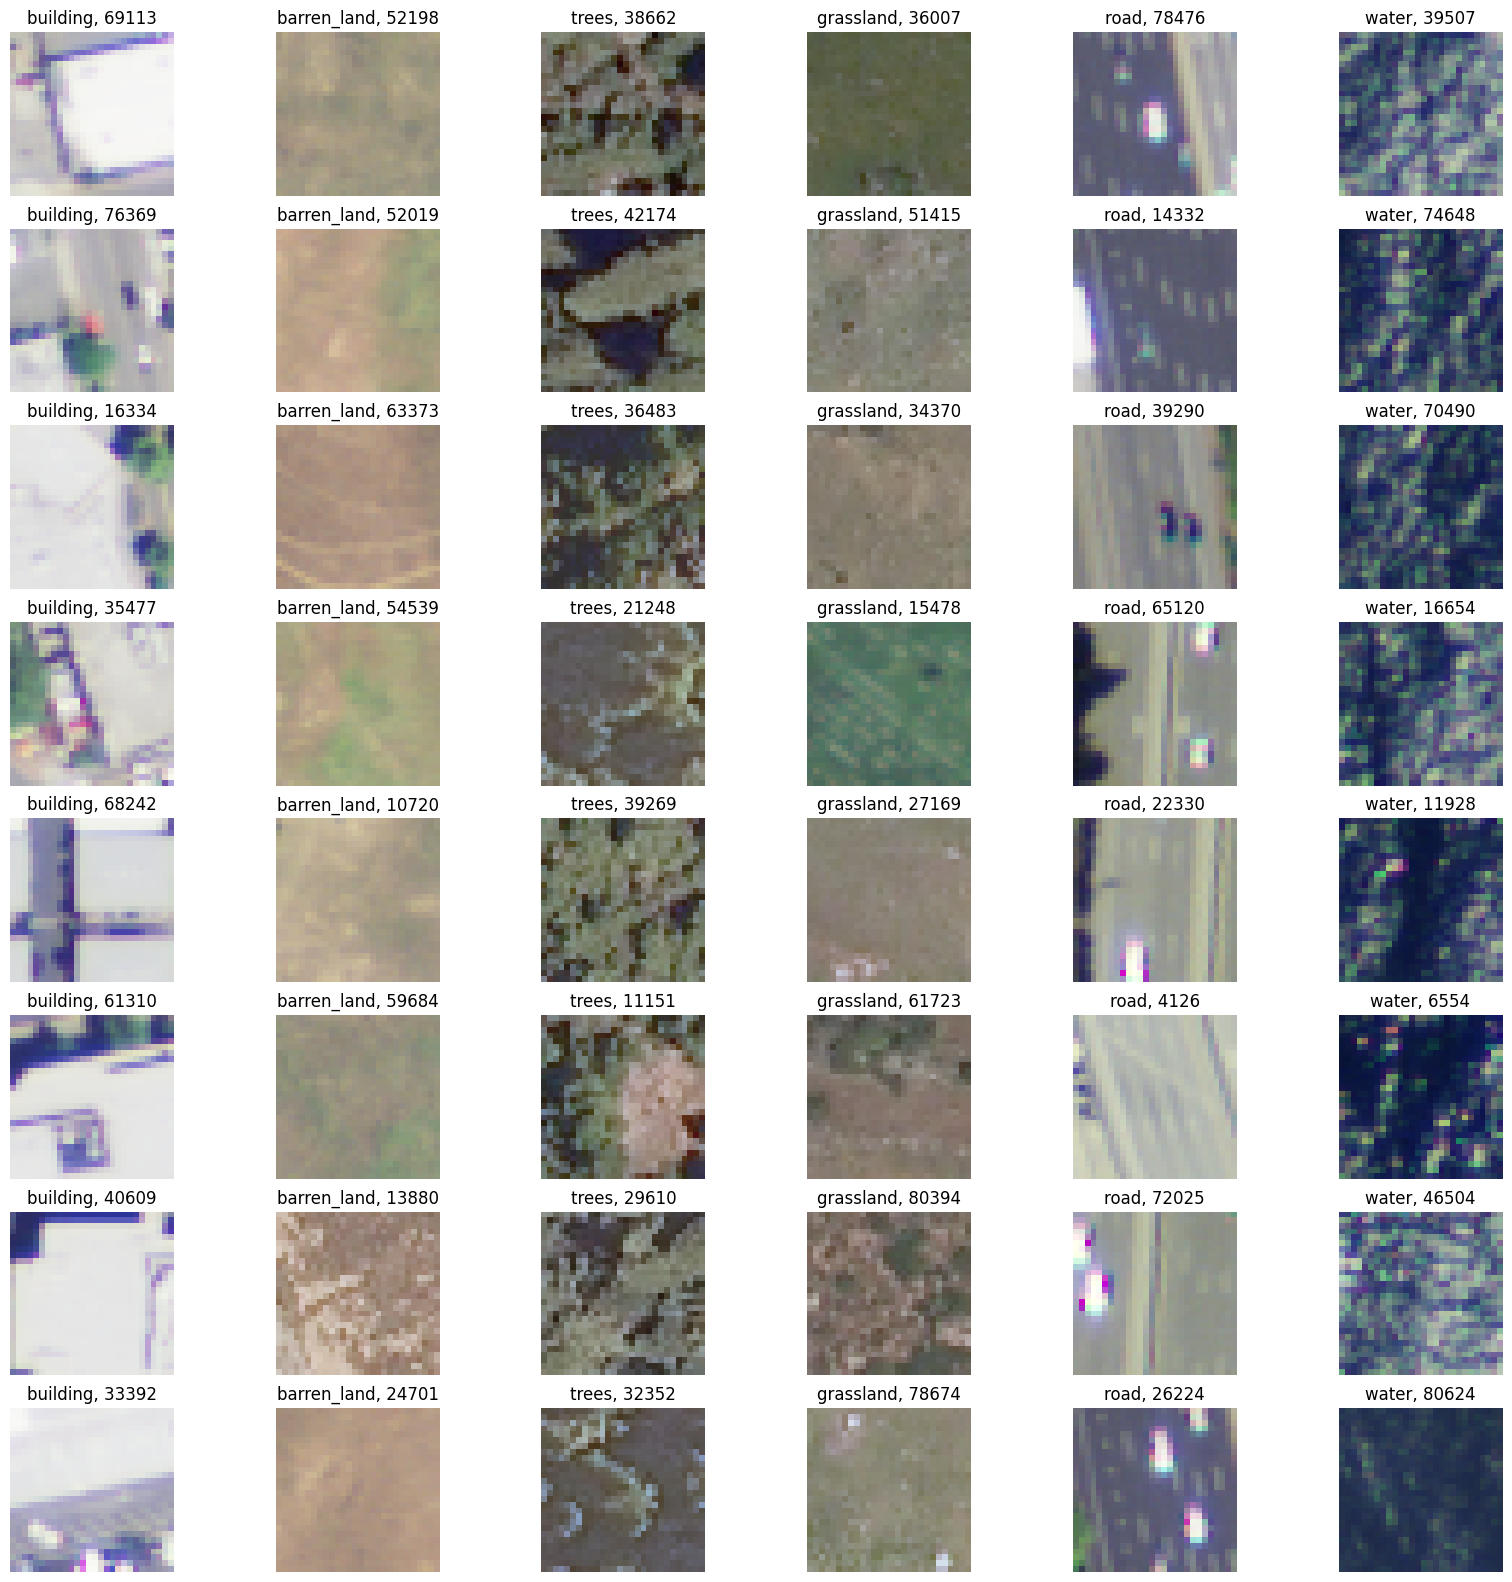

In [ ]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

Collect equal number of samples from each class for training and testing, respectively

In [ ]:
num_train = 1000
num_test = 100
train_idx = []
test_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
    test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 600


&#x1F479;  _Question:_ Why use `extend`here and `append` above?

&#x1F479;  _Question:_ What is wrong with the above code?

In [ ]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets?

In [ ]:
train_X

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
46245,97,88,127,22,82,115,129,20,62,72,...,135,37,123,145,132,37,93,102,126,24
40278,137,129,118,183,129,123,107,175,125,121,...,127,195,129,126,108,184,133,131,119,190
16434,158,154,161,48,150,150,158,47,142,138,...,175,71,187,184,179,78,191,184,182,84
2708,58,48,32,105,58,51,31,103,113,111,...,61,125,74,64,44,113,88,81,50,123
43031,223,225,217,142,185,185,198,106,98,55,...,232,181,238,238,235,189,239,239,236,194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23872,62,69,85,9,102,114,96,15,85,112,...,69,4,28,34,81,5,20,36,85,5
68225,100,105,95,166,102,106,97,162,106,109,...,69,146,69,70,45,122,93,97,82,151
43407,128,121,107,146,128,119,101,146,131,122,...,84,143,110,105,91,146,138,132,118,159
10893,88,89,136,20,97,111,147,23,108,121,...,96,9,44,61,104,10,47,39,98,10


## Define and intialize random classifier from scikit-learn

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

## Train the random forest

In [ ]:
rf.fit( train_X, train_y)

RandomForestClassifier(n_estimators=200)

## Check the prediction on the test set

In [ ]:
rf.score(test_X, test_y)

0.91

&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)

In [ ]:
from sklearn.metrics import classification_report

y_pred = rf.predict(test_X)

print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93       100
           1       0.96      0.91      0.93       100
           2       0.90      0.92      0.91       100
           3       0.93      0.80      0.86       100
           4       0.98      0.92      0.95       100
           5       0.99      1.00      1.00       100

   micro avg       0.95      0.91      0.93       600
   macro avg       0.95      0.91      0.93       600
weighted avg       0.95      0.91      0.93       600
 samples avg       0.91      0.91      0.91       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


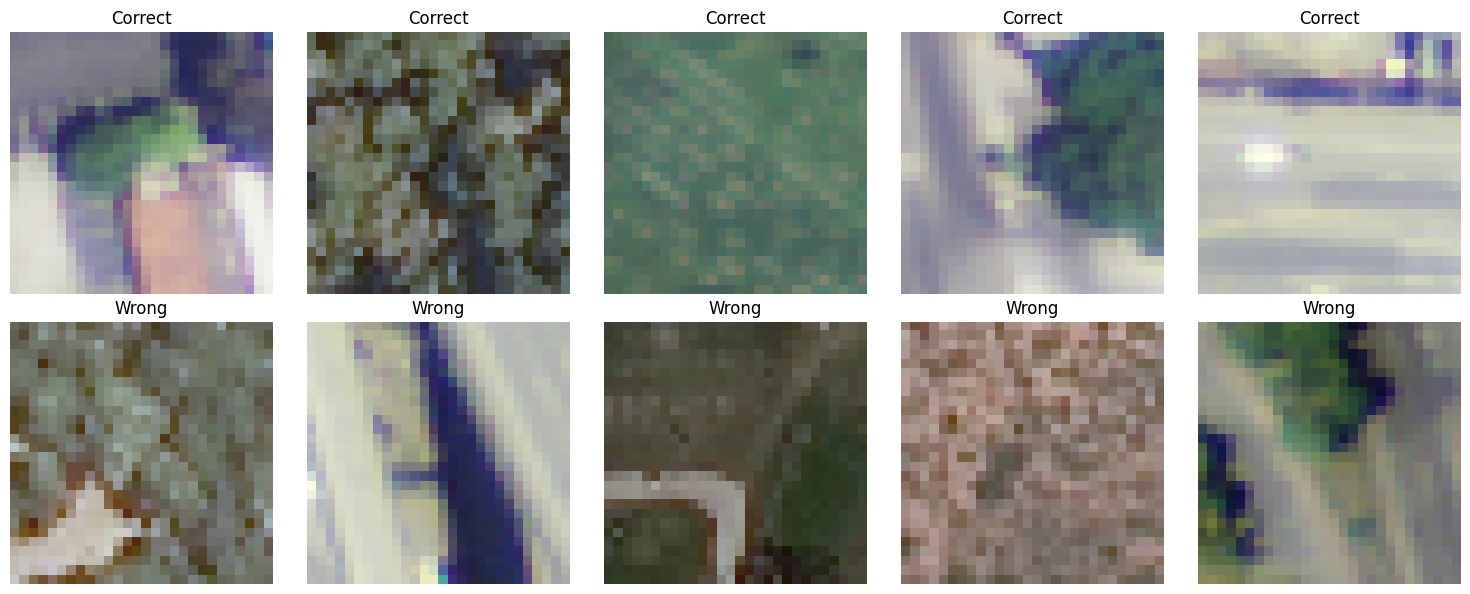

In [ ]:
# Plot successes and failures

y_true = np.argmax(test_y.values, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

success_idx = np.where(y_true == y_pred_class)[0]
failure_idx = np.where(y_true != y_pred_class)[0]

fig, ax = plt.subplots(2, 5, figsize=(15,6))

# Correct predictions
for i in range(5):

    idx = success_idx[i]

    img = test_X.iloc[idx].values
    img = img.reshape(28,28,4)[:,:,0:3]

    img = np.nan_to_num(img)

    ax[0,i].imshow(img.astype(np.uint8))
    ax[0,i].set_title("Correct")
    ax[0,i].axis("off")

# Wrong predictions
for i in range(5):

    idx = failure_idx[i]

    img = test_X.iloc[idx].values
    img = img.reshape(28,28,4)[:,:,0:3]

    img = np.nan_to_num(img)

    ax[1,i].imshow(img.astype(np.uint8))
    ax[1,i].set_title("Wrong")
    ax[1,i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# RGB only experiment

train_x_rgb = train_X.iloc[:, :-1]
test_x_rgb = test_X.iloc[:, :-1]

rf_rgb = RandomForestClassifier()

rf_rgb.fit(train_x_rgb, train_y)

rgb_score = rf_rgb.score(test_x_rgb, test_y)

print("RGB accuracy:", rgb_score)

RGB accuracy: 0.9083333333333333


In [ ]:
# R, G and NIR only

train_x_rgnir = train_X.drop(train_X.columns[2::4], axis=1)
test_x_rgnir = test_X.drop(test_X.columns[2::4], axis=1)

rf_rgnir = RandomForestClassifier()

rf_rgnir.fit(train_x_rgnir, train_y)

rgnir_score = rf_rgnir.score(test_x_rgnir, test_y)

print("RG+NIR accuracy:", rgnir_score)

RG+NIR accuracy: 0.8916666666666667


In [ ]:
# Hyperparameter experiment

rf_new = RandomForestClassifier(
    n_estimators=200
)

rf_new.fit(train_X, train_y)

new_score = rf_new.score(test_X, test_y)

print("New accuracy:", new_score)

New accuracy: 0.9083333333333333


In [ ]:
Conv2D
MaxPooling2D
Dense

keras.src.layers.core.dense.Dense

# Hyperparameter Experiment

I changed the Random Forest hyperparameter `n_estimators` from 100 to 200.

## Expectation

Increasing the number of trees should improve the robustness of the model and may improve the classification accuracy.

## Result

The classification accuracy changed from approximately 0.928 to 0.908.

## Conclusion

Increasing the number of trees from 100 to 200 did not improve the classification performance in this experiment. The accuracy slightly decreased.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
# reshape data for CNN
X_train_cnn = train_X.values.reshape(-1, 28, 28, 4)
X_test_cnn = test_X.values.reshape(-1, 28, 28, 4)

y_train_cnn = train_y.values
y_test_cnn = test_y.values

# build CNN model
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,4)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train model
history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# evaluate
test_loss, test_acc = cnn_model.evaluate(
    X_test_cnn,
    y_test_cnn
)

print("CNN accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.6946 - loss: 3.2836 - val_accuracy: 0.7275 - val_loss: 0.5209
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8183 - loss: 0.4030 - val_accuracy: 0.8417 - val_loss: 0.3675
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8483 - loss: 0.3594 - val_accuracy: 0.8583 - val_loss: 0.3378
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8892 - loss: 0.2718 - val_accuracy: 0.7683 - val_loss: 0.6578
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9031 - loss: 0.2366 - val_accuracy: 0.8908 - val_loss: 0.2747
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9133 - loss: 0.2196 - val_accuracy: 0.9150 - val_loss: 0.2168
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9200 - loss: 0.1998 - val_accuracy: 0.9258 - val_loss: 0.2082
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9377 - loss: 0.1517 - val_acc

## Epoch Experiment

I changed the CNN hyperparameter **epochs** from 5 to 10.

**Expectation:**
Increasing the number of epochs allows the neural network to learn more features from the training data and may improve classification performance.

**Result:**
After training the CNN for 10 epochs, the model achieved a test accuracy of approximately **0.927**.

**Conclusion:**
The model achieved a good classification accuracy after increasing the number of epochs. Training for more epochs helped the network learn the data better, although very large numbers of epochs could eventually lead to overfitting.


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# CNN predictions
y_pred_cnn = cnn_model.predict(X_test_cnn)

y_true_classes = np.argmax(y_test_cnn, axis=1)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)

print(classification_report(y_true_classes, y_pred_classes))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
              precision    recall  f1-score   support

           0       1.00      0.52      0.68       100
           1       0.99      0.80      0.88       100
           2       0.99      0.89      0.94       100
           3       0.75      0.97      0.85       100
           4       0.67      0.99      0.80       100
           5       1.00      1.00      1.00       100

    accuracy                           0.86       600
   macro avg       0.90      0.86      0.86       600
weighted avg       0.90      0.86      0.86       600



In [ ]:
# RGB only CNN

X_train_rgb = X_train_cnn[:, :, :, :3]
X_test_rgb = X_test_cnn[:, :, :, :3]

cnn_rgb = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

cnn_rgb.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_rgb.fit(
    X_train_rgb,
    y_train_cnn,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

rgb_loss, rgb_acc = cnn_rgb.evaluate(X_test_rgb, y_test_cnn)

print("RGB CNN accuracy:", rgb_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6475 - loss: 2.8611 - val_accuracy: 0.8217 - val_loss: 0.4733
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8325 - loss: 0.4362 - val_accuracy: 0.7633 - val_loss: 0.5888
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8783 - loss: 0.3156 - val_accuracy: 0.8858 - val_loss: 0.2946
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8940 - loss: 0.2682 - val_accuracy: 0.8958 - val_loss: 0.3032
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8883 - loss: 0.2735 - val_accuracy: 0.8850 - val_loss: 0.3091
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8883 - loss: 0.2890
RGB CNN accuracy: 0.8883333206176758


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_rgb = cnn_rgb.predict(X_test_rgb)

y_true_classes = np.argmax(y_test_cnn, axis=1)
y_pred_classes = np.argmax(y_pred_rgb, axis=1)

print(classification_report(y_true_classes, y_pred_classes))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       100
           1       0.97      0.87      0.92       100
           2       0.79      0.99      0.88       100
           3       0.85      0.74      0.79       100
           4       0.83      0.91      0.87       100
           5       1.00      1.00      1.00       100

    accuracy                           0.89       600
   macro avg       0.90      0.89      0.89       600
weighted avg       0.90      0.89      0.89       600

